In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from probcs.models.pattern_completion_model import PatternCompletionModel, BinaryPatternCompletionModel
from probcs.experiment_running.exc_experiment import center_surround_experiment, create_stimuli
from probcs.utils.utils import load_images
from torchvision import transforms
import arviz as az
from sklearn.metrics.pairwise import cosine_similarity
from probcs.utils.utils import select_focus_images, get_excitatory_images
from probcs.utils.plotting import plot_posterior_binary
import pickle
import pandas as pd
import os
import glob

seed = 42
rng = np.random.default_rng(seed)

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
results_dict = {
    'stimulus_id': [],
    'big_stimulus': [],
    'small_x_mean': [],
    'small_g_mean': [],
    'big_x_mean': [],
    'big_g_mean': [],
}

# Find all small stimulus .pkl files in the results directory
small_pkl_files = glob.glob("results/coen_cagli_small_stimulus_*.pkl")
print(f"Found {len(small_pkl_files)} small stimulus .pkl files:")
for file in small_pkl_files:
    print(f"  {file}")

# Process each small stimulus .pkl file
for results_path in small_pkl_files:
    # Load the small stimulus pickle file
    with open(results_path, "rb") as f:
        results = pickle.load(f)
        X = results['posterior']['X'].data
        X_mean = X.mean((0, 1))
        G = results['posterior']['G'].data
        G_mean = G.mean((0, 1))
        
        # Extract ID from filename
        stimulus_id = int(results_path.split("_")[-1].strip(".pkl"))
        
        # Load corresponding small stimulus image file
        image_path = results_path.replace("small_stimulus", "big_stimulus").replace(".pkl", ".npy")
        with open(image_path, "rb") as image_f:
            image = np.load(image_f)
        
        # Load corresponding big stimulus results
        big_results_path = f"results/coen_cagli_big_stimulus_results_{stimulus_id}.pkl"
        with open(big_results_path, "rb") as big_f:
            big_results = pickle.load(big_f)
            big_X = big_results['posterior']['X'].data
            big_x_mean = big_X.mean((0, 1))
            big_G = big_results['posterior']['G'].data
            big_g_mean = big_G.mean((0, 1))
        
        # Append to results dictionary
        results_dict['stimulus_id'].append(stimulus_id)
        results_dict['big_stimulus'].append(image)
        results_dict['small_x_mean'].append(X_mean)
        results_dict['small_g_mean'].append(G_mean)
        results_dict['big_x_mean'].append(big_x_mean)
        results_dict['big_g_mean'].append(big_g_mean)
        
        print(f"Processed {results_path} with stimulus_id {stimulus_id}")

# Convert to pandas DataFrame
df = pd.DataFrame(results_dict)

# Add center mean columns
G_dim = 10
center_ids = list(range(G_dim*4, G_dim*4 + G_dim))  # [40, 41, 42, ..., 49]

print(f"Center IDs: {center_ids}")
print(f"This corresponds to indices {G_dim*4} to {G_dim*4 + G_dim - 1}")

# Extract the center region for each small_x_mean and compute its mean
df['small_x_center_mean'] = df['small_x_mean'].apply(lambda x: x[center_ids].mean())

# Extract the center region for each big_x_mean and compute its mean
df['big_x_center_mean'] = df['big_x_mean'].apply(lambda x: x[center_ids].mean())

Found 1000 small stimulus .pkl files:
  results/coen_cagli_small_stimulus_637.pkl
  results/coen_cagli_small_stimulus_792.pkl
  results/coen_cagli_small_stimulus_808.pkl
  results/coen_cagli_small_stimulus_578.pkl
  results/coen_cagli_small_stimulus_849.pkl
  results/coen_cagli_small_stimulus_145.pkl
  results/coen_cagli_small_stimulus_746.pkl
  results/coen_cagli_small_stimulus_285.pkl
  results/coen_cagli_small_stimulus_586.pkl
  results/coen_cagli_small_stimulus_500.pkl
  results/coen_cagli_small_stimulus_903.pkl
  results/coen_cagli_small_stimulus_701.pkl
  results/coen_cagli_small_stimulus_552.pkl
  results/coen_cagli_small_stimulus_200.pkl
  results/coen_cagli_small_stimulus_671.pkl
  results/coen_cagli_small_stimulus_790.pkl
  results/coen_cagli_small_stimulus_964.pkl
  results/coen_cagli_small_stimulus_442.pkl
  results/coen_cagli_small_stimulus_973.pkl
  results/coen_cagli_small_stimulus_352.pkl
  results/coen_cagli_small_stimulus_363.pkl
  results/coen_cagli_small_stimulus_33

In [3]:
df

,stimulus_id,big_stimulus,small_x_mean,small_g_mean,big_x_mean,big_g_mean,small_x_center_mean,big_x_center_mean
0,637,"[[15.239399030293532, 15.161983196569444, 15.2...","[0.32916666666666666, 0.04416666666666667, 0.2...","[0.36916666666666664, 0.025833333333333333, 0....","[0.36333333333333334, 0.2991666666666667, 0.05...","[0.415, 0.3175, 0.0, 0.12666666666666668, 0.75...",0.083083,0.199333
1,792,"[[6.829643283480405, 7.213035983828268, 7.5490...","[0.31583333333333335, 0.095, 0.0475, 0.0358333...","[0.36333333333333334, 0.07833333333333334, 0.0...","[0.08666666666666667, 0.15416666666666667, 0.0...","[0.0575, 0.1725, 0.08, 0.020833333333333332, 0...",0.126167,0.119000
2,808,"[[-9.989868210145852, -11.33450751256781, -10....","[0.24166666666666667, 0.041666666666666664, 0....","[0.25, 0.0, 0.0, 0.0, 0.28583333333333333, 0.5...","[0.1025, 0.050833333333333335, 0.2133333333333...","[0.06416666666666666, 0.018333333333333333, 0....",0.092583,0.101583
3,578,"[[-5.727389269980294, -5.4591987031504186, -5....","[0.245, 0.235, 0.049166666666666664, 0.0366666...","[0.24333333333333335, 0.25, 0.0, 0.0, 0.064166...","[0.25833333333333336, 0.13833333333333334, 0.0...","[0.2916666666666667, 0.1375, 0.06, 0.1775, 0.1...",0.087750,0.119833
4,849,"[[-8.031431940340056, -9.952081910351954, -11....","[0.24, 0.11083333333333334, 0.2375, 0.16, 0.09...","[0.24666666666666667, 0.10916666666666666, 0.2...","[0.10416666666666667, 0.059166666666666666, 0....","[0.07333333333333333, 0.041666666666666664, 0....",0.108750,0.085583
...,...,...,...,...,...,...,...,...
995,895,"[[14.202579828631642, 14.125163994907552, 14.3...","[0.04666666666666667, 0.029166666666666667, 0....","[0.0, 0.0, 0.035833333333333335, 0.5, 0.37, 0....","[0.22916666666666666, 0.13, 0.0391666666666666...","[0.26416666666666666, 0.09, 0.0, 0.40333333333...",0.091250,0.105083
996,700,"[[10.400909422538035, 10.208291455295958, 10.1...","[0.2758333333333333, 0.04, 0.0375, 0.055833333...","[0.30583333333333335, 0.0, 0.0, 0.0, 0.165, 0....","[0.09, 0.22583333333333333, 0.085, 0.216666666...","[0.05, 0.20666666666666667, 0.0475, 0.215, 0.3...",0.067000,0.103083
997,799,"[[-12.409113014023601, -12.48652884774769, -11...","[0.365, 0.0475, 0.056666666666666664, 0.2275, ...","[0.44166666666666665, 0.0175, 0.0, 0.228333333...","[0.085, 0.034166666666666665, 0.06333333333333...","[0.025833333333333333, 0.008333333333333333, 0...",0.091750,0.064250
998,487,"[[1.0695366075810018, 1.1073229073749007, 1.67...","[0.18833333333333332, 0.04083333333333333, 0.0...","[0.19166666666666668, 0.0, 0.0, 0.25, 0.103333...","[0.5058333333333334, 0.08916666666666667, 0.09...","[0.6083333333333333, 0.07416666666666667, 0.06...",0.075833,0.144250


In [5]:
# Create a dictionary to store the top 200 stimulus IDs for each center neuron
top_activating_stimuli = {}

# For each center neuron
for i, center_neuron_idx in enumerate(center_ids):
    # Extract the activation values for this specific center neuron across all stimuli
    neuron_activations = df['small_x_mean'].apply(lambda x: x[center_neuron_idx])
    
    # Get the indices of the top 200 most activating stimuli
    top_200_indices = neuron_activations.nlargest(200).index
    
    # Get the corresponding stimulus IDs
    top_200_stimulus_ids = df.loc[top_200_indices, 'stimulus_id'].tolist()
    
    # Store in dictionary
    neuron_name = f'center_neuron_{i}'  # neuron 0-9
    top_activating_stimuli[neuron_name] = top_200_stimulus_ids
    
    print(f"Center neuron {i} (index {center_neuron_idx}): Top 200 stimulus IDs")
    print(f"  Max activation: {neuron_activations.max():.4f}")
    print(f"  Min activation in top 200: {neuron_activations.iloc[top_200_indices].min():.4f}")
    print(f"  Sample stimulus IDs: {top_200_stimulus_ids[:10]}")

print(f"Created dictionary with {len(top_activating_stimuli)} center neurons")
print(f"Each neuron has {len(top_activating_stimuli['center_neuron_0'])} top activating stimulus IDs")

Center neuron 0 (index 40): Top 200 stimulus IDs
  Max activation: 0.5267
  Min activation in top 200: 0.2875
  Sample stimulus IDs: [543, 889, 601, 304, 883, 800, 117, 372, 339, 111]
Center neuron 1 (index 41): Top 200 stimulus IDs
  Max activation: 0.3517
  Min activation in top 200: 0.1200
  Sample stimulus IDs: [436, 276, 452, 750, 746, 646, 795, 515, 53, 131]
Center neuron 2 (index 42): Top 200 stimulus IDs
  Max activation: 0.4117
  Min activation in top 200: 0.1183
  Sample stimulus IDs: [496, 386, 525, 162, 646, 323, 746, 424, 979, 824]
Center neuron 3 (index 43): Top 200 stimulus IDs
  Max activation: 0.3667
  Min activation in top 200: 0.0692
  Sample stimulus IDs: [471, 340, 338, 973, 817, 207, 261, 777, 233, 854]
Center neuron 4 (index 44): Top 200 stimulus IDs
  Max activation: 0.5908
  Min activation in top 200: 0.1958
  Sample stimulus IDs: [555, 850, 350, 393, 815, 4, 25, 697, 240, 565]
Center neuron 5 (index 45): Top 200 stimulus IDs
  Max activation: 0.4500
  Min acti

In [8]:
top_activating_stimuli

{'center_neuron_0': [543,
  889,
  601,
  304,
  883,
  800,
  117,
  372,
  339,
  111,
  546,
  947,
  652,
  218,
  574,
  145,
  90,
  740,
  841,
  395,
  880,
  938,
  634,
  135,
  73,
  976,
  324,
  366,
  541,
  998,
  917,
  866,
  7,
  441,
  933,
  84,
  829,
  130,
  888,
  956,
  192,
  179,
  342,
  737,
  499,
  826,
  943,
  877,
  229,
  937,
  596,
  840,
  705,
  217,
  174,
  951,
  955,
  210,
  163,
  212,
  454,
  878,
  333,
  946,
  95,
  417,
  328,
  870,
  453,
  413,
  612,
  722,
  9,
  223,
  142,
  68,
  193,
  294,
  437,
  194,
  610,
  205,
  572,
  364,
  235,
  497,
  220,
  822,
  703,
  402,
  18,
  265,
  397,
  975,
  88,
  742,
  173,
  274,
  954,
  391,
  586,
  58,
  896,
  1,
  431,
  94,
  881,
  501,
  838,
  919,
  825,
  971,
  99,
  104,
  912,
  711,
  148,
  439,
  374,
  119,
  427,
  979,
  170,
  306,
  359,
  687,
  189,
  296,
  51,
  614,
  605,
  195,
  983,
  361,
  763,
  421,
  196,
  300,
  103,
  799,
  714,
  984,
  49

In [9]:
# Create a more organized DataFrame for analysis
top_stimuli_data = []

for neuron_name, stimulus_ids in top_activating_stimuli.items():
    neuron_idx = int(neuron_name.split('_')[-1])  # Extract neuron index (0-9)
    center_neuron_pos = center_ids[neuron_idx]  # Get the actual position in x_mean (40-49)
    
    for rank, stimulus_id in enumerate(stimulus_ids):
        # Get the activation value for this stimulus and neuron
        row_idx = df[df['stimulus_id'] == stimulus_id].index[0]
        
        # Current center neuron activation
        small_center_x_mean = df.loc[row_idx, 'small_x_mean'][center_neuron_pos]
        big_center_x_mean = df.loc[row_idx, 'big_x_mean'][center_neuron_pos]
        
        # Get full arrays for small and big stimulus
        small_x_full = df.loc[row_idx, 'small_x_mean']
        big_x_full = df.loc[row_idx, 'big_x_mean']
        small_g_full = df.loc[row_idx, 'small_g_mean']
        big_g_full = df.loc[row_idx, 'big_g_mean']
        
        # All center neurons (include all 10 center neurons)
        small_all_center_array = small_x_full[center_ids]
        big_all_center_array = big_x_full[center_ids]
        
        # All neurons (include all neurons, preserving order)
        small_all_other_array = small_x_full
        big_all_other_array = big_x_full
        
        # All G neurons
        small_g_array = small_g_full
        big_g_array = big_g_full
        
        top_stimuli_data.append({
            'neuron_idx': neuron_idx,
            'center_neuron_pos': center_neuron_pos,
            'stimulus_id': stimulus_id,
            'rank': rank + 1,  # 1-indexed rank
            'small_x_center': small_center_x_mean,
            'big_x_center': big_center_x_mean,
            'small_x_all_center_array': small_all_center_array,
            'big_x_all_center_array': big_all_center_array,
            'small_x_all_other_array': small_all_other_array,
            'big_x_all_other_array': big_all_other_array,
            'small_g_array': small_g_array,
            'big_g_array': big_g_array
        })

# Create DataFrame
top_stimuli_df = pd.DataFrame(top_stimuli_data)

In [10]:
top_stimuli_df

,neuron_idx,center_neuron_pos,stimulus_id,rank,small_x_center,big_x_center,small_x_all_center_array,big_x_all_center_array,small_x_all_other_array,big_x_all_other_array,small_g_array,big_g_array
0,0,40,543,1,0.526667,0.258333,"[0.5266666666666666, 0.09416666666666666, 0.03...","[0.25833333333333336, 0.0075, 0.13583333333333...","[0.5675, 0.12083333333333333, 0.06083333333333...","[0.30833333333333335, 0.04416666666666667, 0.2...","[0.6891666666666667, 0.12166666666666667, 0.02...","[0.3516666666666667, 0.0, 0.21083333333333334,..."
1,0,40,889,2,0.510000,0.325000,"[0.51, 0.016666666666666666, 0.028333333333333...","[0.325, 0.051666666666666666, 0.02916666666666...","[0.6, 0.035833333333333335, 0.0475, 0.10833333...","[0.385, 0.09166666666666666, 0.0475, 0.2633333...","[0.7416666666666667, 0.0008333333333333334, 0....","[0.4558333333333333, 0.059166666666666666, 0.0..."
2,0,40,601,3,0.509167,0.165833,"[0.5091666666666667, 0.019166666666666665, 0.0...","[0.16583333333333333, 0.050833333333333335, 0....","[0.5625, 0.043333333333333335, 0.0683333333333...","[0.16333333333333333, 0.135, 0.088333333333333...","[0.6916666666666667, 0.0008333333333333334, 0....","[0.1475, 0.07666666666666666, 0.05166666666666..."
3,0,40,304,4,0.503333,0.156667,"[0.5033333333333333, 0.021666666666666667, 0.0...","[0.15666666666666668, 0.04416666666666667, 0.1...","[0.57, 0.04083333333333333, 0.0741666666666666...","[0.1475, 0.10083333333333333, 0.23083333333333...","[0.6891666666666667, 0.005833333333333334, 0.0...","[0.15333333333333332, 0.07166666666666667, 0.2..."
4,0,40,883,5,0.500000,0.225833,"[0.5, 0.010833333333333334, 0.0183333333333333...","[0.22583333333333333, 0.07583333333333334, 0.0...","[0.585, 0.029166666666666667, 0.05, 0.0875, 0....","[0.22833333333333333, 0.10583333333333333, 0.0...","[0.6916666666666667, 0.0008333333333333334, 0....","[0.23583333333333334, 0.10833333333333334, 0.0..."
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,9,49,915,196,0.081667,0.054167,"[0.10416666666666667, 0.009166666666666667, 0....","[0.24833333333333332, 0.0175, 0.02666666666666...","[0.11833333333333333, 0.04583333333333333, 0.0...","[0.2633333333333333, 0.03, 0.05, 0.26333333333...","[0.10416666666666667, 0.0, 0.0, 0.3875, 0.1475...","[0.2916666666666667, 0.0, 0.0, 0.3116666666666..."
1996,9,49,811,197,0.081667,0.006667,"[0.15666666666666668, 0.05333333333333334, 0.0...","[0.10083333333333333, 0.023333333333333334, 0....","[0.20333333333333334, 0.09166666666666666, 0.0...","[0.12416666666666666, 0.04, 0.1875, 0.14916666...","[0.20416666666666666, 0.0775, 0.0, 0.0, 0.205,...","[0.1075, 0.010833333333333334, 0.19, 0.14, 0.0..."
1997,9,49,320,198,0.081667,0.011667,"[0.03916666666666667, 0.0925, 0.09166666666666...","[0.04833333333333333, 0.06583333333333333, 0.1...","[0.0575, 0.165, 0.14666666666666667, 0.2475, 0...","[0.03666666666666667, 0.11416666666666667, 0.2...","[0.020833333333333332, 0.16666666666666666, 0....","[0.0, 0.10583333333333333, 0.2275, 0.0, 0.1608..."
1998,9,49,551,199,0.080833,0.212500,"[0.3, 0.09166666666666666, 0.01916666666666666...","[0.18666666666666668, 0.155, 0.046666666666666...","[0.37833333333333335, 0.11666666666666667, 0.0...","[0.19916666666666666, 0.2025, 0.08833333333333...","[0.44166666666666665, 0.11416666666666667, 0.0...","[0.20083333333333334, 0.1875, 0.0525, 0.206666..."


In [11]:
# Analysis: Compare small vs big stimulus center activations
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the difference between big and small center activations
top_stimuli_df['center_activation_ratio'] = top_stimuli_df['big_x_center'] / top_stimuli_df['small_x_center']
top_stimuli_df['center_activation_diff'] = top_stimuli_df['big_x_center'] - top_stimuli_df['small_x_center']

# Summary statistics
print("=== Small vs Big Stimulus Center Activation Analysis ===")
print(f"Total number of stimulus-neuron pairs: {len(top_stimuli_df)}")
print()

print("Summary Statistics:")
print(f"Small stimulus center activation - Mean: {top_stimuli_df['small_x_center'].mean():.4f}, Std: {top_stimuli_df['small_x_center'].std():.4f}")
print(f"Big stimulus center activation - Mean: {top_stimuli_df['big_x_center'].mean():.4f}, Std: {top_stimuli_df['big_x_center'].std():.4f}")
print(f"Activation ratio (big / small) - Mean: {top_stimuli_df['center_activation_ratio'].mean():.4f}, Std: {top_stimuli_df['center_activation_ratio'].std():.4f}")
print()

# Check how many cases have higher/lower activation with big stimulus
higher_with_big = (top_stimuli_df['big_x_center'] > top_stimuli_df['small_x_center']).sum()
lower_with_big = (top_stimuli_df['big_x_center'] < top_stimuli_df['small_x_center']).sum()
equal = (top_stimuli_df['big_x_center'] == top_stimuli_df['small_x_center']).sum()

print("Comparison Results:")
print(f"Cases where big stimulus has HIGHER activation: {higher_with_big} ({100*higher_with_big/len(top_stimuli_df):.1f}%)")
print(f"Cases where big stimulus has LOWER activation: {lower_with_big} ({100*lower_with_big/len(top_stimuli_df):.1f}%)")
print(f"Cases where activations are EQUAL: {equal} ({100*equal/len(top_stimuli_df):.1f}%)")
print()

# Analysis by neuron
print("Analysis by Center Neuron:")
neuron_analysis = top_stimuli_df.groupby('neuron_idx').agg({
    'small_x_center': ['mean', 'std'],
    'big_x_center': ['mean', 'std'],
    'center_activation_ratio': ['mean', 'std'],
    'center_activation_diff': ['mean', 'std'],
}).round(4)

print(neuron_analysis)

=== Small vs Big Stimulus Center Activation Analysis ===
Total number of stimulus-neuron pairs: 2000

Summary Statistics:
Small stimulus center activation - Mean: 0.1960, Std: 0.0930
Big stimulus center activation - Mean: 0.1139, Std: 0.1074
Activation ratio (big / small) - Mean: 0.6032, Std: 0.5373

Comparison Results:
Cases where big stimulus has HIGHER activation: 389 (19.4%)
Cases where big stimulus has LOWER activation: 1607 (80.3%)
Cases where activations are EQUAL: 4 (0.2%)

Analysis by Center Neuron:
           small_x_center         big_x_center          \
                     mean     std         mean     std   
neuron_idx                                               
0                  0.3414  0.0491       0.1553  0.0993   
1                  0.1640  0.0459       0.0705  0.0691   
2                  0.1769  0.0472       0.0791  0.0643   
3                  0.1069  0.0391       0.0446  0.0385   
4                  0.2868  0.0796       0.1964  0.1323   
5                  0.2

In [12]:
# Calculate Modulation Ratio (MR) and Geometric Mean
# MR = big_response / small_response (same as center_activation_ratio)
# MR < 1: surround suppression
# MR > 1: facilitation

# Filter for images that evoked a measurable response (non-zero small stimulus activation)
measurable_responses = top_stimuli_df[top_stimuli_df['small_x_center'] > 0].copy()

print("=== Modulation Ratio (MR) Analysis ===")
print(f"Total stimulus-neuron pairs: {len(top_stimuli_df)}")
print(f"Pairs with measurable response (small_x_center > 0): {len(measurable_responses)}")
print(f"Percentage with measurable response: {100 * len(measurable_responses) / len(top_stimuli_df):.1f}%")
print()

if len(measurable_responses) > 0:
    # Calculate geometric mean of MR
    from scipy import stats
    
    # Geometric mean using scipy
    geometric_mean_mr = stats.gmean(measurable_responses['center_activation_ratio'])
    
    # Alternative calculation: exp(mean(log(MR)))
    geometric_mean_mr_alt = np.exp(np.log(measurable_responses['center_activation_ratio']).mean())
    
    print("Modulation Ratio (MR) Statistics:")
    print(f"Arithmetic mean MR: {measurable_responses['center_activation_ratio'].mean():.4f}")
    print(f"Geometric mean MR: {geometric_mean_mr:.4f}")
    print(f"Geometric mean MR (alternative calc): {geometric_mean_mr_alt:.4f}")
    print(f"Median MR: {measurable_responses['center_activation_ratio'].median():.4f}")
    print()
    
    # Classification of responses
    suppression = (measurable_responses['center_activation_ratio'] < 1).sum()
    facilitation = (measurable_responses['center_activation_ratio'] > 1).sum()
    no_change = (measurable_responses['center_activation_ratio'] == 1).sum()
    
    print("Response Classification:")
    print(f"Surround suppression (MR < 1): {suppression} ({100*suppression/len(measurable_responses):.1f}%)")
    print(f"Facilitation (MR > 1): {facilitation} ({100*facilitation/len(measurable_responses):.1f}%)")
    print(f"No change (MR = 1): {no_change} ({100*no_change/len(measurable_responses):.1f}%)")
    print()
    
    print(f"*** The geometric mean of the MR for natural images that evoked a measurable response was {geometric_mean_mr:.4f} ***")
    
    if geometric_mean_mr < 1:
        print("This indicates overall SURROUND SUPPRESSION when enlarging stimuli.")
    elif geometric_mean_mr > 1:
        print("This indicates overall FACILITATION when enlarging stimuli.")
    else:
        print("This indicates NO NET EFFECT when enlarging stimuli.")
        
else:
    print("No measurable responses found!")

=== Modulation Ratio (MR) Analysis ===
Total stimulus-neuron pairs: 2000
Pairs with measurable response (small_x_center > 0): 2000
Percentage with measurable response: 100.0%

Modulation Ratio (MR) Statistics:
Arithmetic mean MR: 0.6032
Geometric mean MR: 0.3948
Geometric mean MR (alternative calc): 0.3948
Median MR: 0.4433

Response Classification:
Surround suppression (MR < 1): 1607 (80.3%)
Facilitation (MR > 1): 389 (19.4%)
No change (MR = 1): 4 (0.2%)

*** The geometric mean of the MR for natural images that evoked a measurable response was 0.3948 ***
This indicates overall SURROUND SUPPRESSION when enlarging stimuli.


/tmp/ipykernel_3980923/838443663.py:34: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  axes[0, 0].plot([0, top_stimuli_df['small_x_center'].max()],


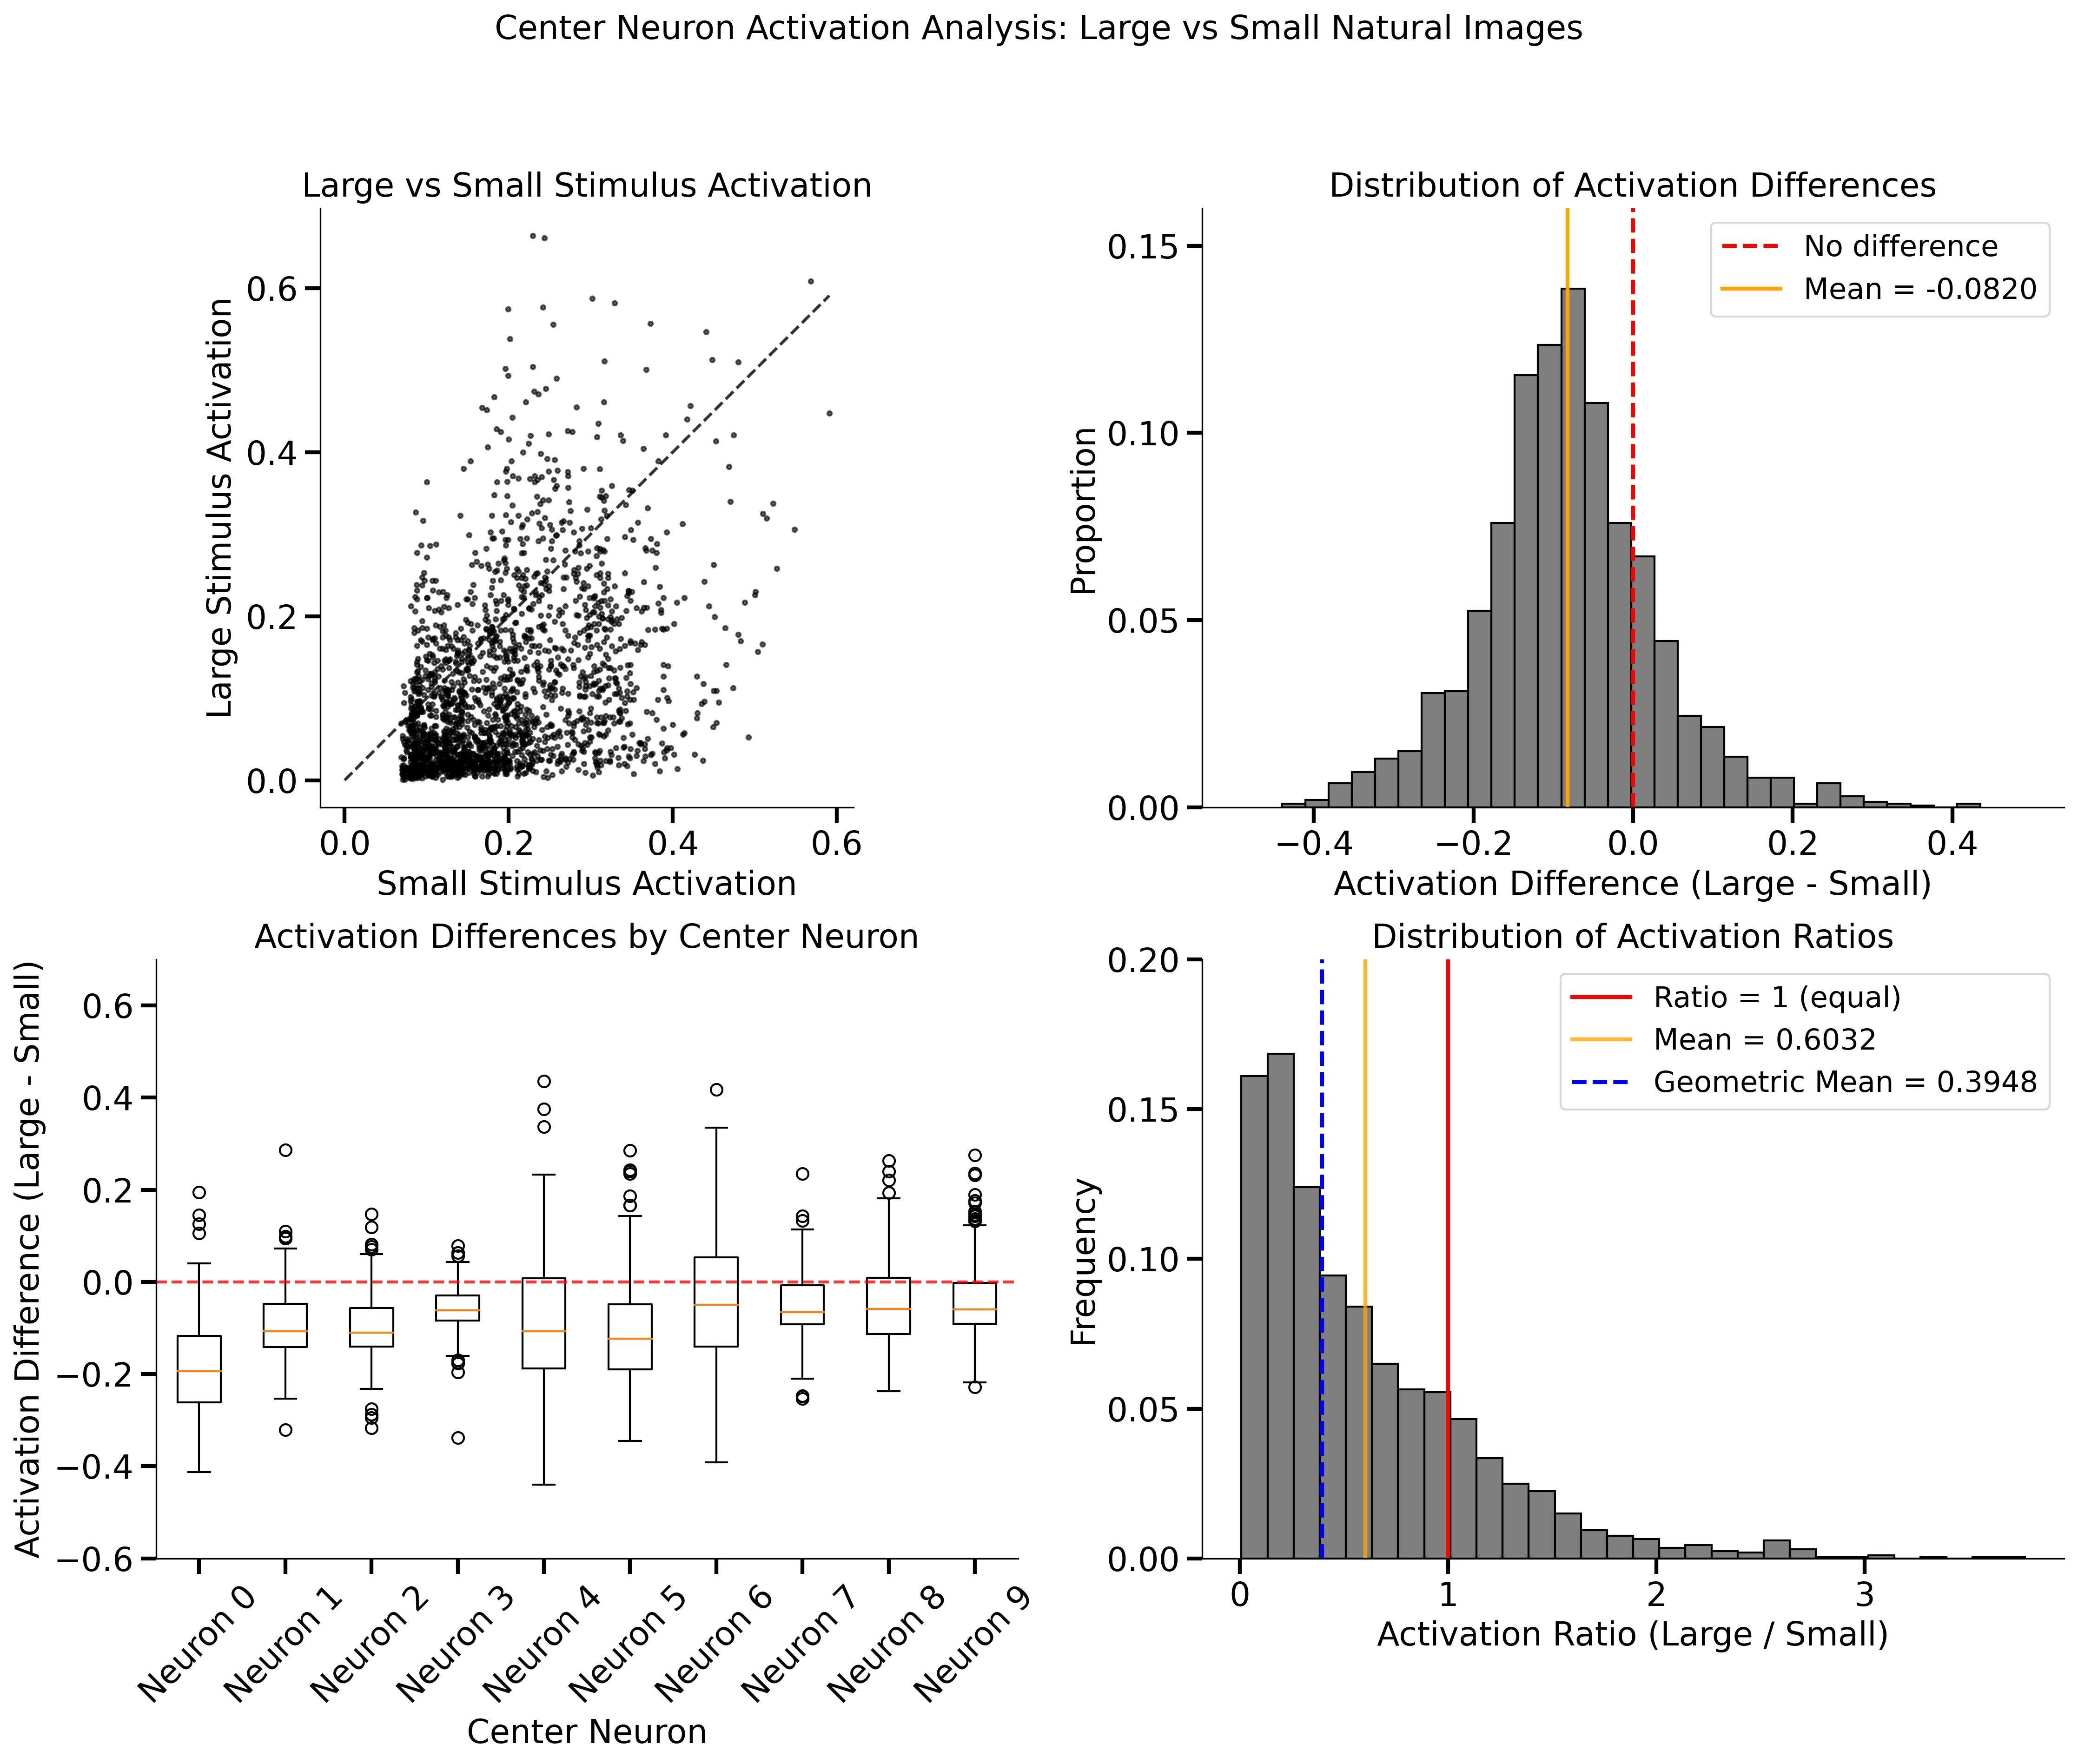

In [14]:
scatter_alpha = 0.6
yx_alpha = 0.8
yx_color = "black"
grid_alpha = 0.3
scatter_size = 5
scatter_color = "black"
xlabel_size = 17
ylabel_size = 17
title_size = 17
tick_label_size = 17
tick_length = 8
tick_width = 2

bins = 30
bar_alpha = 0.5
bar_color = 'black'
edge_color = 'black'
no_diffline_color = 'red'
no_diffline_width = 2

mean_line_color = 'orange'
mean_line_width = 2

legend_size = 15


# Visualizations: Small vs Big Stimulus Center Activations
fig, axes = plt.subplots(2, 2, figsize=(15, 12), dpi=300)


# 1. Scatter plot: Small vs Big activation
axes[0, 0].scatter(top_stimuli_df['small_x_center'], top_stimuli_df['big_x_center'], 
                   alpha=scatter_alpha, s=scatter_size, color=scatter_color)
axes[0, 0].plot([0, top_stimuli_df['small_x_center'].max()], 
                [0, top_stimuli_df['small_x_center'].max()], 'r--', alpha=yx_alpha, color=yx_color)
axes[0, 0].set_xticks(np.arange(0, top_stimuli_df['small_x_center'].max() + 0.1, 0.2))
axes[0, 0].set_yticks(np.arange(0, top_stimuli_df['small_x_center'].max() + 0.1, 0.2))
axes[0, 0].set_xlabel('Small Stimulus Activation', fontsize=xlabel_size)
axes[0, 0].set_ylabel('Large Stimulus Activation', fontsize=ylabel_size)
axes[0, 0].set_title('Large vs Small Stimulus Activation', fontsize=title_size)
axes[0, 0].set_aspect('equal', adjustable='box')

# 2. Distribution of activation differences
sns.histplot(top_stimuli_df['center_activation_diff'], bins=bins, alpha=bar_alpha, edgecolor=edge_color, color=bar_color, 
             ax=axes[0, 1], stat='proportion')
# axes[0, 1].hist(top_stimuli_df['center_activation_diff'], bins=bins, alpha=bar_alpha, edgecolor=edge_color, color=bar_color, density=True)
axes[0, 1].axvline(0, color=no_diffline_color, linewidth=no_diffline_width, linestyle='--', label='No difference')
axes[0, 1].axvline(top_stimuli_df['center_activation_diff'].mean(), color=mean_line_color, linewidth=mean_line_width,
                   linestyle='-', label=f'Mean = {top_stimuli_df["center_activation_diff"].mean():.4f}')
axes[0, 1].set_xlim(top_stimuli_df['center_activation_diff'].min() - 0.1, 
                    abs(top_stimuli_df['center_activation_diff'].min()) + 0.1)
axes[0, 1].set_xlabel('Activation Difference (Large - Small)', fontsize=xlabel_size)
axes[0, 1].set_ylabel('Proportion', fontsize=ylabel_size)
axes[0, 1].set_title('Distribution of Activation Differences', fontsize=title_size)
axes[0, 1].set_yticks(np.arange(0, 0.16, 0.05))
axes[0, 1].set_ylim(0, 0.16)
axes[0, 1].legend(prop={'size': legend_size})

# 3. Box plot by neuron
neuron_data = []
neuron_labels = []
for neuron_idx in sorted(top_stimuli_df['neuron_idx'].unique()):
    neuron_subset = top_stimuli_df[top_stimuli_df['neuron_idx'] == neuron_idx]
    neuron_data.append(neuron_subset['center_activation_diff'])
    neuron_labels.append(f'Neuron {neuron_idx}')

axes[1, 0].boxplot(neuron_data, labels=neuron_labels)
axes[1, 0].set_xlabel('Center Neuron', fontsize=xlabel_size)
axes[1, 0].set_ylabel('Activation Difference (Large - Small)', fontsize=ylabel_size)
axes[1, 0].set_title('Activation Differences by Center Neuron', fontsize=title_size)
axes[1, 0].tick_params(axis='x', rotation=45, labelsize=tick_label_size)
axes[1, 0].set_ylim((-0.6, 0.7))
axes[1, 0].axhline(0, color='red', linestyle='--', alpha=0.8)

# 4. Activation ratio distribution
sns.histplot(top_stimuli_df['center_activation_ratio'], bins=bins, alpha=bar_alpha, edgecolor=edge_color, color=bar_color, 
             ax=axes[1, 1], stat='proportion')
axes[1, 1].axvline(1, linestyle='-', color=no_diffline_color, label='Ratio = 1 (equal)', linewidth=no_diffline_width)
axes[1, 1].axvline(top_stimuli_df['center_activation_ratio'].mean(), color=mean_line_color, linewidth=mean_line_width,
                   linestyle='-', alpha=0.8, label=f'Mean = {top_stimuli_df["center_activation_ratio"].mean():.4f}')
axes[1, 1].axvline(geometric_mean_mr, color='blue', linewidth=mean_line_width,
                   linestyle='--', label=f'Geometric Mean = {geometric_mean_mr:.4f}')
axes[1, 1].set_xlabel('Activation Ratio (Large / Small)', fontsize=xlabel_size)
axes[1, 1].set_ylabel('Frequency', fontsize=ylabel_size)
axes[1, 1].set_title('Distribution of Activation Ratios', fontsize=title_size)
axes[1, 1].legend(prop={'size': legend_size})
axes[1, 1].set_yticks(np.arange(0, 0.21, 0.05))

for ax in axes.flat:
    ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
    ax.tick_params(axis='both', which='minor', labelsize=tick_label_size)
    # ax.set_aspect('equal', adjustable='box')
    ax.tick_params(axis='both', which='both', length=tick_length, width=tick_width)
    sns.despine(ax=ax)
fig.suptitle('Center Neuron Activation Analysis: Large vs Small Natural Images', fontsize=title_size, y=1.05)
plt.tight_layout()
plt.show()
fig.savefig('large_vs_small_natimgs_center_neuron.pdf', dpi=300, bbox_inches='tight')

In [16]:
# Analysis: G neuron responses to small vs big stimuli
# Understanding if inhibitory G neurons drive the center X neuron effects

print("=== G Neuron (Inhibitory) Response Analysis ===")
print(f"Total stimulus-neuron pairs: {len(top_stimuli_df)}")
print()

# Add G neuron mean activations to our analysis DataFrame
top_stimuli_df['small_g_mean'] = top_stimuli_df['small_g_array'].apply(lambda x: x.mean())
top_stimuli_df['big_g_mean'] = top_stimuli_df['big_g_array'].apply(lambda x: x.mean())
top_stimuli_df['g_activation_diff'] = top_stimuli_df['big_g_mean'] - top_stimuli_df['small_g_mean']
top_stimuli_df['g_activation_ratio'] = top_stimuli_df['big_g_mean'] / top_stimuli_df['small_g_mean']

top_stimuli_df['small_g_star'] = top_stimuli_df.apply(
    lambda row: row['small_g_array'][row['neuron_idx']], axis=1
)
top_stimuli_df['big_g_star'] = top_stimuli_df.apply(
    lambda row: row['big_g_array'][row['neuron_idx']], axis=1
)
top_stimuli_df['g_star_activation_ratio'] = top_stimuli_df['big_g_star'] / top_stimuli_df['small_g_star']

top_stimuli_df['small_g_others'] = top_stimuli_df.apply(
    lambda row: np.mean([row['small_g_array'][i] for i in range(len(row['small_g_array'])) if i != row['neuron_idx']]), axis=1
)
top_stimuli_df['big_g_others'] = top_stimuli_df.apply(
    lambda row: np.mean([row['big_g_array'][i] for i in range(len(row['big_g_array'])) if i != row['neuron_idx']]), axis=1
)
top_stimuli_df['g_others_activation_ratio'] = top_stimuli_df['big_g_others'] / top_stimuli_df['small_g_others']


=== G Neuron (Inhibitory) Response Analysis ===
Total stimulus-neuron pairs: 2000



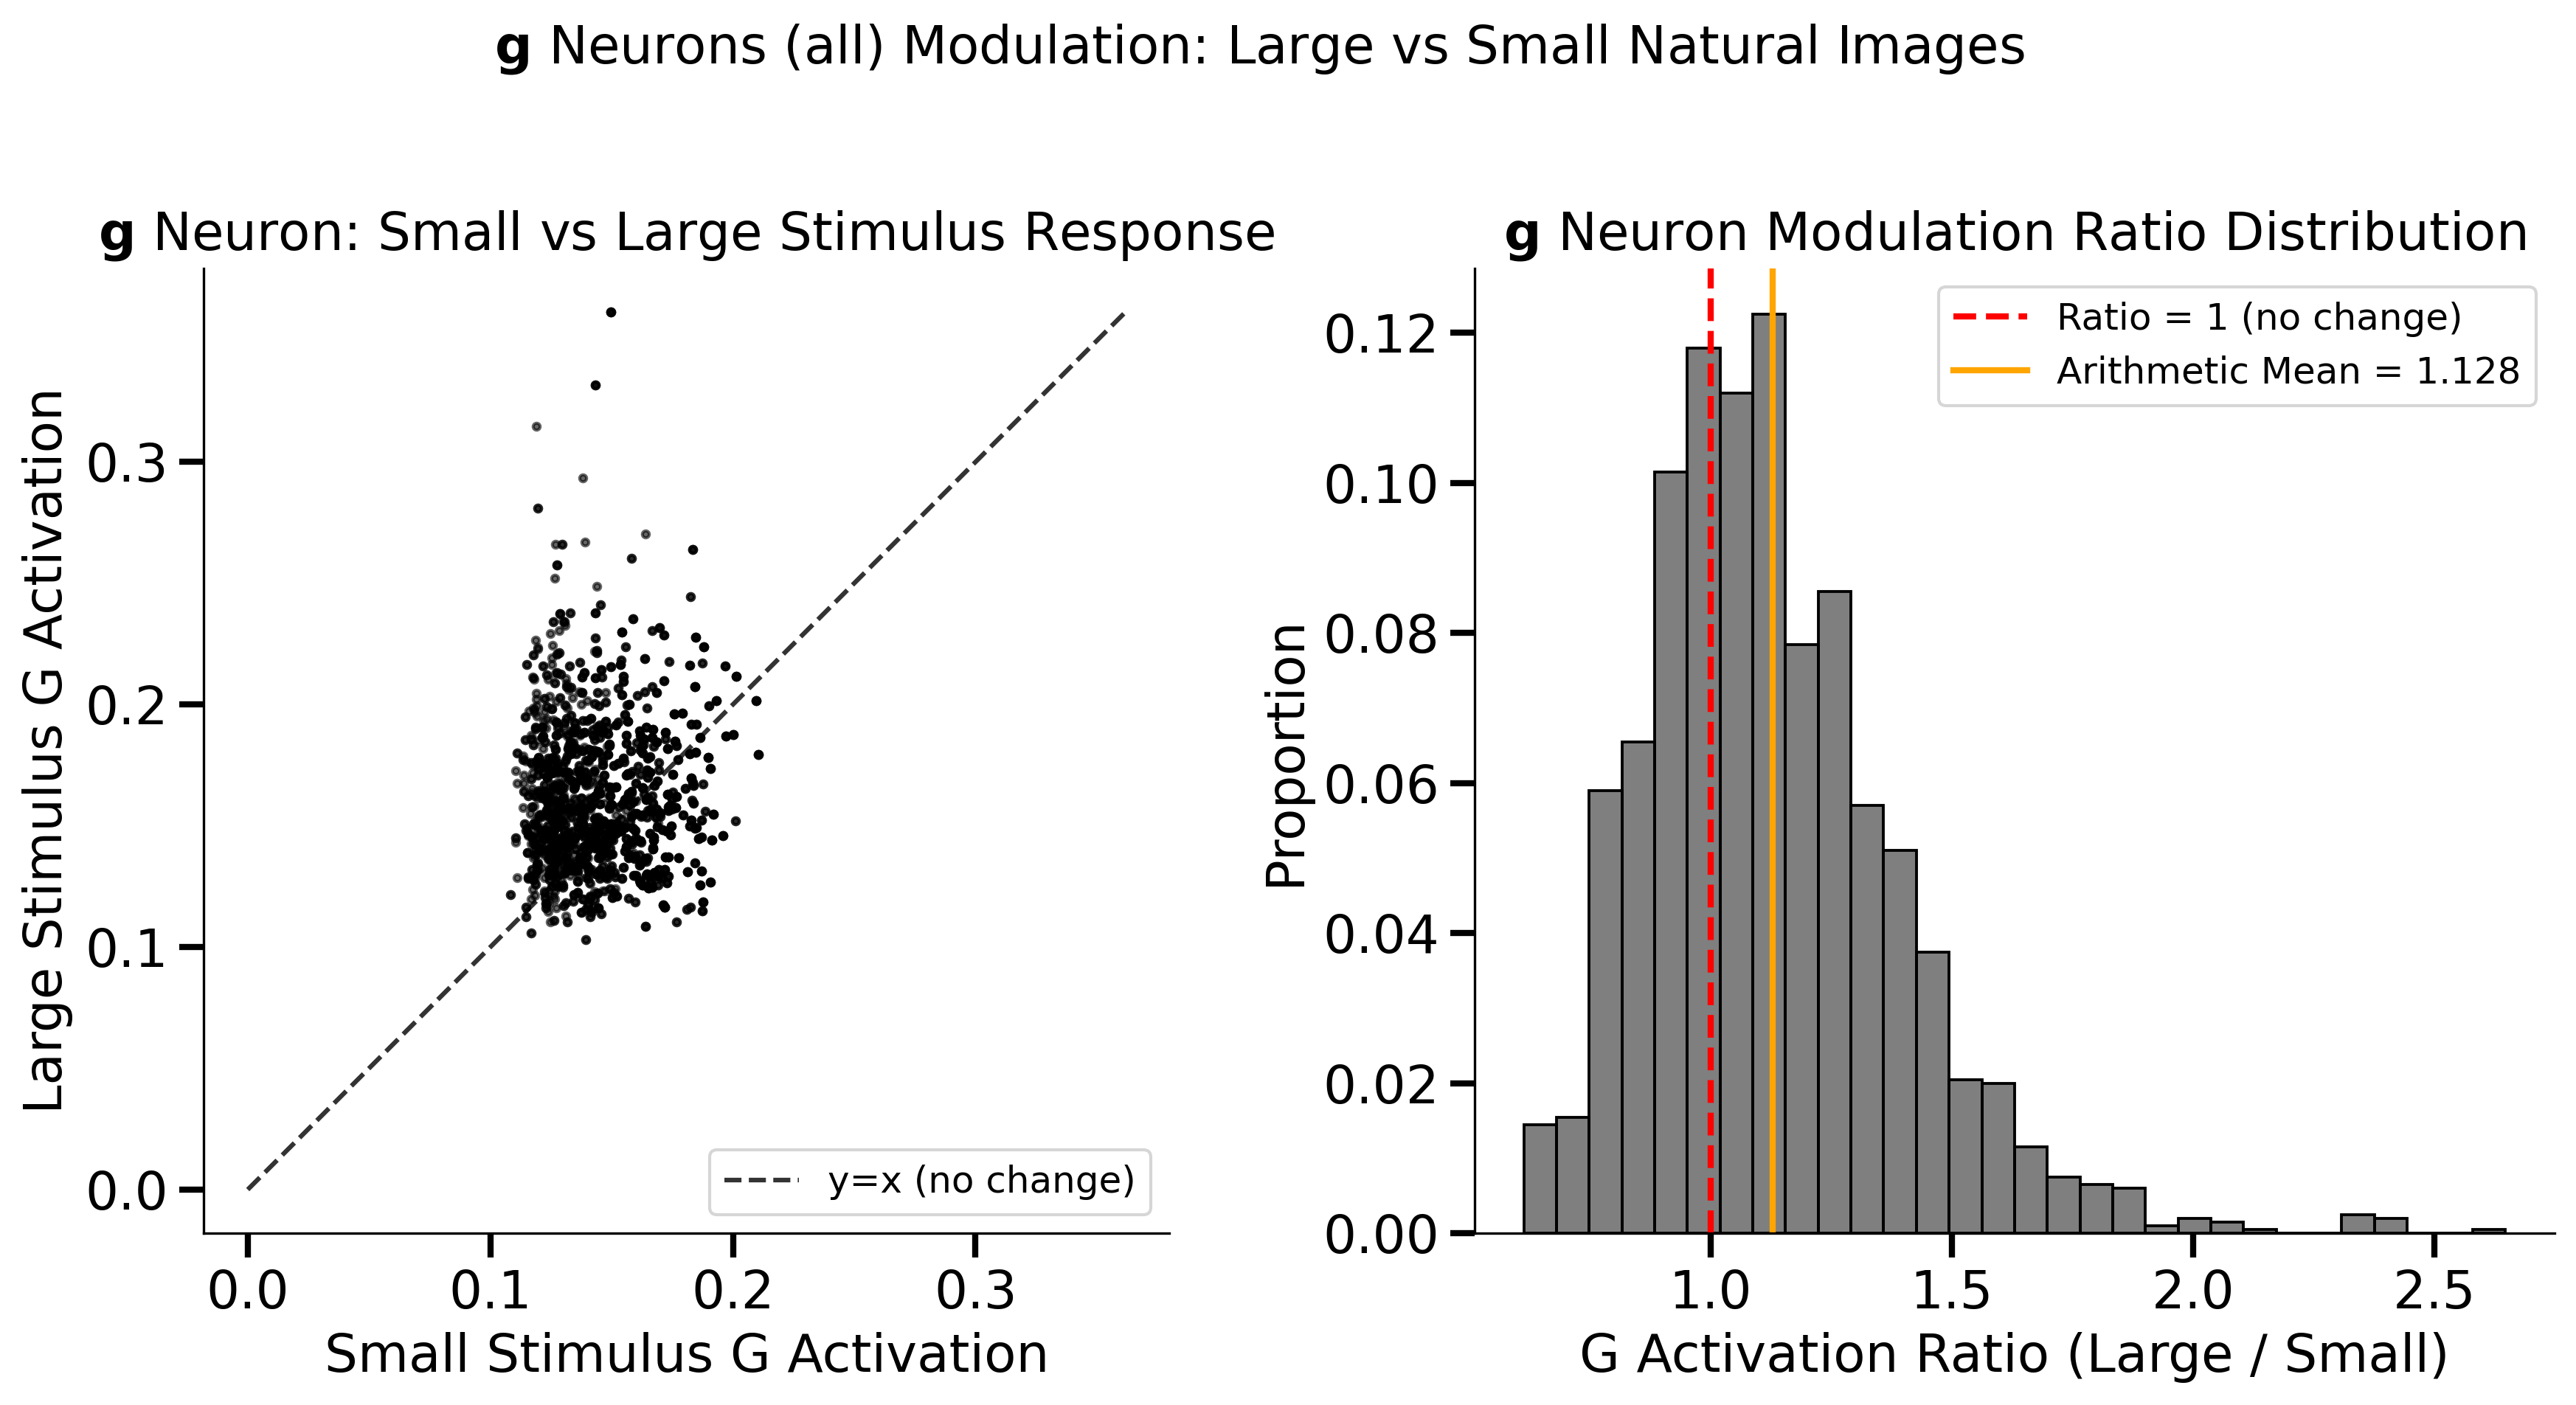

In [17]:
# Comprehensive Visualization: $\\mathbf{g}$ Neuron Inhibitory Response Analysis
# Style parameters
scatter_alpha = 0.6
yx_alpha = 0.8
yx_color = "black"
grid_alpha = 0.3
scatter_size = 5
scatter_color = "black"
xlabel_size = 17
ylabel_size = 17
title_size = 17
tick_label_size = 17
tick_length = 8
tick_width = 2

bins = 30
bar_alpha = 0.5
bar_color = 'black'
edge_color = 'black'
no_diffline_color = 'red'
no_diffline_width = 2

mean_line_color = 'orange'
mean_line_width = 2

legend_size = 12

fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=300)

# 1. G Neuron Responses: Small vs Big
axes[0].scatter(top_stimuli_df['small_g_mean'], top_stimuli_df['big_g_mean'], 
                alpha=scatter_alpha, s=scatter_size, color=scatter_color)
axes[0].plot([0.0, top_stimuli_df['big_g_mean'].max()], 
             [0.0, top_stimuli_df['big_g_mean'].max()], '--', alpha=yx_alpha, color=yx_color, label='y=x (no change)')
axes[0].set_xlabel('Small Stimulus G Activation', fontsize=xlabel_size)
axes[0].set_ylabel('Large Stimulus G Activation', fontsize=ylabel_size)
axes[0].set_title('$\\mathbf{g}$ Neuron: Small vs Large Stimulus Response', fontsize=title_size)
axes[0].set_xticks(np.arange(0.0, top_stimuli_df['big_g_mean'].max() + 0.01, 0.1))
axes[0].set_yticks(np.arange(0.0, top_stimuli_df['big_g_mean'].max() + 0.01, 0.1))
axes[0].legend(prop={'size': legend_size})
axes[0].set_aspect('equal', adjustable='box')

# 2. $\\mathbf{g}$ Neuron Activation Ratio Distribution
sns.histplot(top_stimuli_df['g_activation_ratio'], bins=bins, alpha=bar_alpha, 
             edgecolor=edge_color, color=bar_color, ax=axes[1], stat='proportion')
axes[1].axvline(1, color=no_diffline_color, linestyle='--', linewidth=no_diffline_width, label='Ratio = 1 (no change)')
mean_g_mr = top_stimuli_df['g_activation_ratio'].mean()
axes[1].axvline(mean_g_mr, color=mean_line_color, linestyle='-', linewidth=mean_line_width,
                label=f'Arithmetic Mean = {mean_g_mr:.3f}')
axes[1].set_xlabel('G Activation Ratio (Large / Small)', fontsize=xlabel_size)
axes[1].set_ylabel('Proportion', fontsize=ylabel_size)
axes[1].set_title('$\\mathbf{g}$ Neuron Modulation Ratio Distribution', fontsize=title_size)
axes[1].legend(prop={'size': legend_size})

# Apply consistent styling to both axes
for ax in axes.flat:
    ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
    ax.tick_params(axis='both', which='minor', labelsize=tick_label_size)
    ax.tick_params(axis='both', which='both', length=tick_length, width=tick_width)
    sns.despine(ax=ax)

fig.suptitle('$\\mathbf{g}$ Neurons (all) Modulation: Large vs Small Natural Images', fontsize=title_size, y=1.05)
plt.tight_layout()
plt.show()
fig.savefig('g_neuron_all_large_vs_small_natimgs.pdf', dpi=300, bbox_inches='tight')

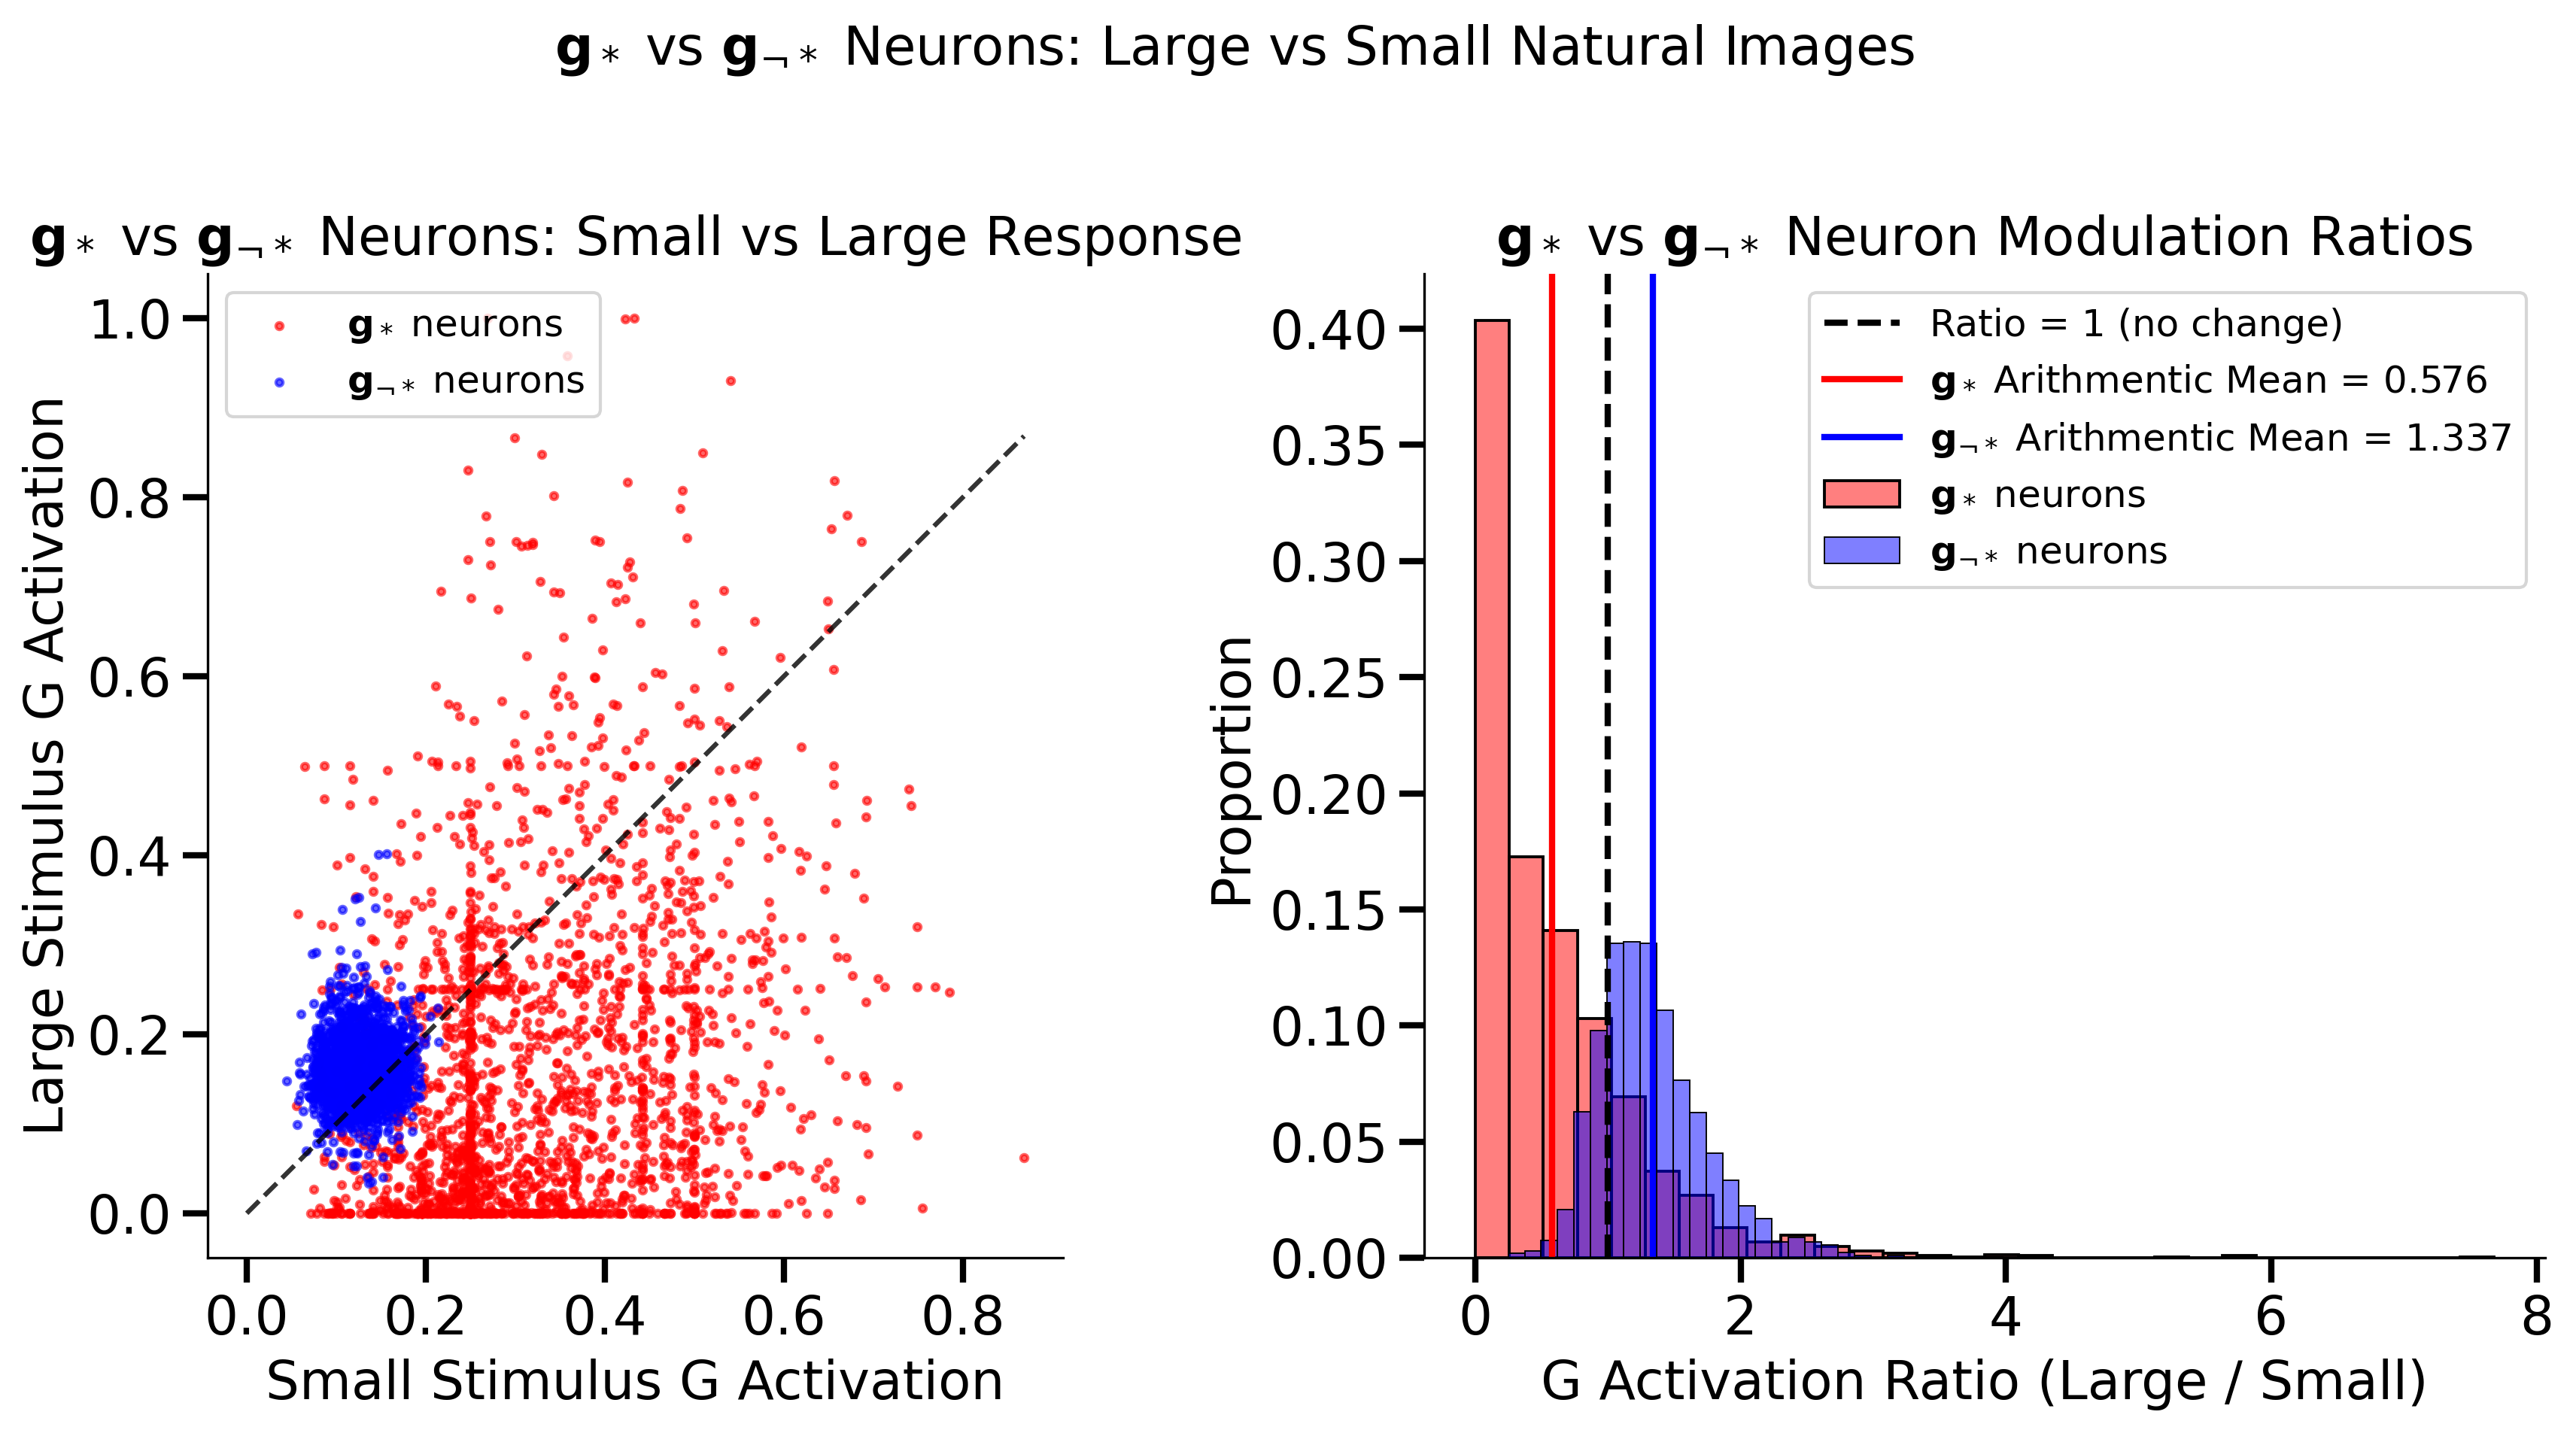

In [51]:
# $\\mathbf{g}_*$ vs $\\mathbf{g}_{\neg *}$ Neurons Comparison Visualization
# Extract "$\\mathbf{g}_{\neg *}$ neuron" responses for comparison
# Style parameters
scatter_alpha = 0.6
yx_alpha = 0.8
yx_color = "black"
scatter_size = 5
g_star_color = "red"
g_others_color = "blue"
xlabel_size = 17
ylabel_size = 17
title_size = 17
tick_label_size = 17
tick_length = 8
tick_width = 2

bins = 30
bar_alpha = 0.5
edge_color = 'black'
no_diffline_color = 'black'
no_diffline_width = 2
mean_line_width = 2
legend_size = 12

fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=300)

# 1. $\mathbf{g}_*$ vs $\mathbf{g}_{\neg *}$ Neuron Responses: Small vs Large
axes[0].scatter(top_stimuli_df['small_g_star'], top_stimuli_df['big_g_star'], 
                alpha=scatter_alpha, s=scatter_size, color=g_star_color, label='$\\mathbf{g}_*$ neurons')
axes[0].scatter(top_stimuli_df['small_g_others'], top_stimuli_df['big_g_others'], 
                alpha=scatter_alpha, s=scatter_size, color=g_others_color, label='$\\mathbf{g}_{\\neg *}$ neurons')
axes[0].plot([0, max(top_stimuli_df['small_g_star'].max(), top_stimuli_df['small_g_others'].max())], 
             [0, max(top_stimuli_df['small_g_star'].max(), top_stimuli_df['small_g_others'].max())], 
             '--', alpha=yx_alpha, color=yx_color)
axes[0].set_xlabel('Small Stimulus G Activation', fontsize=xlabel_size)
axes[0].set_ylabel('Large Stimulus G Activation', fontsize=ylabel_size)
axes[0].set_title(r'$\mathbf{g}_*$ vs $\mathbf{g}_{\neg *}$ Neurons: Small vs Large Response', fontsize=title_size)
axes[0].legend(prop={'size': legend_size}, loc='upper left')
axes[0].set_aspect('equal', adjustable='box')

# 2. $\mathbf{g}_*$ vs $\mathbf{g}_{\neg *}$ Neuron Activation Ratio Distribution
sns.histplot(top_stimuli_df['g_star_activation_ratio'], bins=bins, alpha=bar_alpha, 
             edgecolor=edge_color, color=g_star_color, ax=axes[1], stat='proportion', label='$\\mathbf{g}_*$ neurons')
sns.histplot(top_stimuli_df['g_others_activation_ratio'], bins=bins, alpha=bar_alpha, 
             edgecolor=edge_color, color=g_others_color, ax=axes[1], stat='proportion', label='$\\mathbf{g}_{\\neg *}$ neurons')

axes[1].axvline(1, color=no_diffline_color, linestyle='--', linewidth=no_diffline_width, label='Ratio = 1 (no change)')

# Add arithmetic means
arithmetic_mean_g_star_mr = top_stimuli_df['g_star_activation_ratio'].mean()
axes[1].axvline(arithmetic_mean_g_star_mr, color=g_star_color, linestyle='-', linewidth=mean_line_width,
                label=f'$\\mathbf{{g}}_*$ Arithmentic Mean = {arithmetic_mean_g_star_mr:.3f}')

arithmetic_mean_g_others_mr = top_stimuli_df['g_others_activation_ratio'].mean()
axes[1].axvline(arithmetic_mean_g_others_mr, color=g_others_color, linestyle='-', linewidth=mean_line_width,
                label=f'$\\mathbf{{g}}_{{\\neg *}}$ Arithmentic Mean = {arithmetic_mean_g_others_mr:.3f}')

axes[1].set_xlabel('G Activation Ratio (Large / Small)', fontsize=xlabel_size)
axes[1].set_ylabel('Proportion', fontsize=ylabel_size)
axes[1].set_title(r'$\mathbf{g}_*$ vs $\mathbf{g}_{\neg *}$ Neuron Modulation Ratios', fontsize=title_size)
axes[1].legend(prop={'size': legend_size})

# Apply consistent styling to both axes
for ax in axes.flat:
    ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
    ax.tick_params(axis='both', which='minor', labelsize=tick_label_size)
    ax.tick_params(axis='both', which='both', length=tick_length, width=tick_width)
    sns.despine(ax=ax)

fig.suptitle(r'$\mathbf{g}_*$ vs $\mathbf{g}_{\neg *}$ Neurons: Large vs Small Natural Images', fontsize=title_size, y=1.05)
plt.tight_layout()
plt.show()
fig.savefig('g_star_vs_other_g_neurons_natimgs.pdf', dpi=300, bbox_inches='tight')